# Cross-validation against brutus on the TSLTE grid

[brutus](https://github.com/joshspeagle/brutus) (Speagle et al.) fits stellar
photometry against MIST isochrone grids with a brute-force Bayesian scan — the
closest published analog to tengri-stars' photometry channel. Here the mock star
comes **from the TSLTE grid itself** (A. Chiti's Turbospectrum LTE synthetic
photometry, notebook 03), in the 8 bands both systems share (SDSS ugri + DECam
ugri), so the comparison measures two things at once:

1. **prior structure** — brutus confines models to the MIST manifold with IMF /
   age / Galactic priors; tengri-stars fits a flat atmosphere box;
2. **grid-to-grid systematics** — brutus predicts photometry from its C3K/MIST
   machinery while the data were generated from Turbospectrum LTE, so any
   physics difference between the synthetic grids lands in brutus's residuals
   (tengri-stars fits the generating grid and carries no mismatch by
   construction).

No parallax is given to brutus: the TSLTE magnitude zero-point is a
convention (absorbed by tengri-stars' μ), so an implied distance would be
meaningless. Only (Teff, log g, [Fe/H]) are compared.

In [1]:
import os

# JAX's XLA and numba's default OpenMP threading layer both load libomp —
# a duplicate-runtime segfault on macOS. numba's workqueue layer avoids libomp.
os.environ.setdefault("NUMBA_THREADING_LAYER", "workqueue")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")  # silence XLA/PJRT C++ chatter
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import time
from pathlib import Path

# Notebook kernels launch in notebooks/; scripts run from the repo root.
DATA = (
    Path("data") if (Path("data") / "TSLTE_combined_photometry.fits").exists() else Path("../data")
)

import h5py
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from brutus import utils as brutus_utils
from brutus.analysis import BruteForce
from brutus.core.individual import StarGrid
from brutus.data.download import fetch_grids
from brutus.data.loader import load_models
from tengri import Uniform

from tengri_stars import StarModel, fit_nss, load_photometry_grid, overlay_corner

jax.config.update("jax_enable_x64", True)
rng = np.random.default_rng(9)

## 1. Grids and the shared bands

In [2]:
BRUTUS_GRID = str(fetch_grids(grid="mist_v9", target_dir=str(DATA / "brutus")))
tslte = load_photometry_grid(DATA / "TSLTE_combined_photometry.fits", fill="nearest")

# TSLTE column → brutus filter name, for the bands both systems provide.
BAND_MAP = {
    "SLOAN-SDSS.u_ab": "SDSS_u",
    "SLOAN-SDSS.g_ab": "SDSS_g",
    "SLOAN-SDSS.r_ab": "SDSS_r",
    "SLOAN-SDSS.i_ab": "SDSS_i",
    "DECCAM_u_des_ab": "DECam_u",
    "DECCAM_g_des_ab": "DECam_g",
    "DECCAM_r_des_ab": "DECam_r",
    "DECCAM_i_des_ab": "DECam_i",
}
TSLTE_BANDS = list(BAND_MAP)
BRUTUS_BANDS = list(BAND_MAP.values())
fidx = jnp.asarray([tslte.filter_names.index(f) for f in TSLTE_BANDS])
print(f"{len(BAND_MAP)} shared bands:", BRUTUS_BANDS)

8 shared bands: ['SDSS_u', 'SDSS_g', 'SDSS_r', 'SDSS_i', 'DECam_u', 'DECam_g', 'DECam_r', 'DECam_i']


## 2. Mock star from the TSLTE table

A metal-poor giant on grid nodes (guaranteed inside coverage), zero
extinction (the grid is a bare atmosphere), and a magnitude offset μ that
stands in for distance/radius/zero-point.

In [3]:
TRUTH = {"teff": 4600.0, "logg": 2.0, "feh": -1.5, "mu": -14.0}
SIG_MAG = 0.02

model = StarModel(grid=tslte, interp_method="pchip")
mags_clean = model.predict_mags(**TRUTH)[fidx]
mags_obs = np.asarray(mags_clean) + rng.normal(0.0, SIG_MAG, len(TSLTE_BANDS))
print("observed mags:", dict(zip(BRUTUS_BANDS, np.round(mags_obs, 3))))

observed mags: {'SDSS_u': np.float64(15.189), 'SDSS_g': np.float64(13.782), 'SDSS_r': np.float64(12.959), 'SDSS_i': np.float64(12.701), 'DECam_u': np.float64(15.101), 'DECam_g': np.float64(13.663), 'DECam_r': np.float64(12.93), 'DECam_i': np.float64(12.648)}


## 3. brutus fit (BruteForce over MIST v9, no parallax)

In [4]:
models, labels, label_mask = load_models(BRUTUS_GRID, filters=BRUTUS_BANDS, verbose=False)
star_grid = StarGrid(models, labels, filters=BRUTUS_BANDS, verbose=False)
bf = BruteForce(star_grid, verbose=False)

flux_obs, flux_err = brutus_utils.inv_magnitude(mags_obs, np.full(len(BRUTUS_BANDS), SIG_MAG))

t0 = time.time()
bf.fit(
    flux_obs[None, :],
    flux_err[None, :],
    np.ones((1, len(BRUTUS_BANDS)), dtype=bool),
    np.array([0]),  # object ID (h5py rejects unicode labels)
    str(DATA / "brutus" / "tslte_mock_fit"),
    data_coords=np.array([[90.0, 60.0]]),  # halo sightline for the Galactic prior
    av_gauss=(0.0, 0.01),  # bare-atmosphere mock: extinction pinned at zero
    Ndraws=1000,
    rstate=np.random.RandomState(4),
    verbose=True,
)
print(f"brutus wall time: {time.time() - t0:.1f} s")

with h5py.File(DATA / "brutus" / "tslte_mock_fit.h5", "r") as f:
    model_idx = f["model_idx"][0]
brutus_samples = {
    "teff": 10.0 ** labels["logt"][model_idx],
    "logg": labels["logg"][model_idx],
    "feh": labels["feh"][model_idx],
}
print("brutus medians:", {k: round(float(np.median(v)), 3) for k, v in brutus_samples.items()})

Fitting object 1/1  

Fitting object 1/1 [chi2/n: 82.1/8] (mean time: 0.283 s/obj, total: 0.283 s)    


brutus wall time: 0.9 s
brutus medians: {'teff': 4779.071, 'logg': 4.721, 'feh': -1.2}


## 4. tengri-stars fit on the same TSLTE grid

In [5]:
lo_hi = [(float(a[0]), float(a[-1])) for a in tslte.axes]
priors = {
    "teff": Uniform(*lo_hi[0]),
    "logg": Uniform(*lo_hi[1]),
    "feh": Uniform(*lo_hi[2]),
    "mu": Uniform(-24.0, -4.0),
}
obs = jnp.asarray(mags_obs)


def loglikelihood(p):
    pred = model.predict_mags(teff=p["teff"], logg=p["logg"], feh=p["feh"], mu=p["mu"])[fidx]
    return -0.5 * jnp.sum(((pred - obs) / SIG_MAG) ** 2)


t0 = time.time()
ts = fit_nss(loglikelihood, priors, key=jax.random.PRNGKey(21), n_live=400, num_delete=40)
print(
    f"tengri-stars NSS wall time: {time.time() - t0:.1f} s,  "
    f"log Z = {ts.logz:.1f}, ESS = {ts.ess:.0f}"
)
print("tengri-stars medians:", {k: round(v, 3) for k, v in ts.median().items()})

tengri-stars NSS wall time: 4.2 s,  log Z = -17.7, ESS = 2221
tengri-stars medians: {'teff': 4788.292, 'logg': 0.853, 'feh': -1.538, 'mu': -13.762}


## 5. Posterior overlay

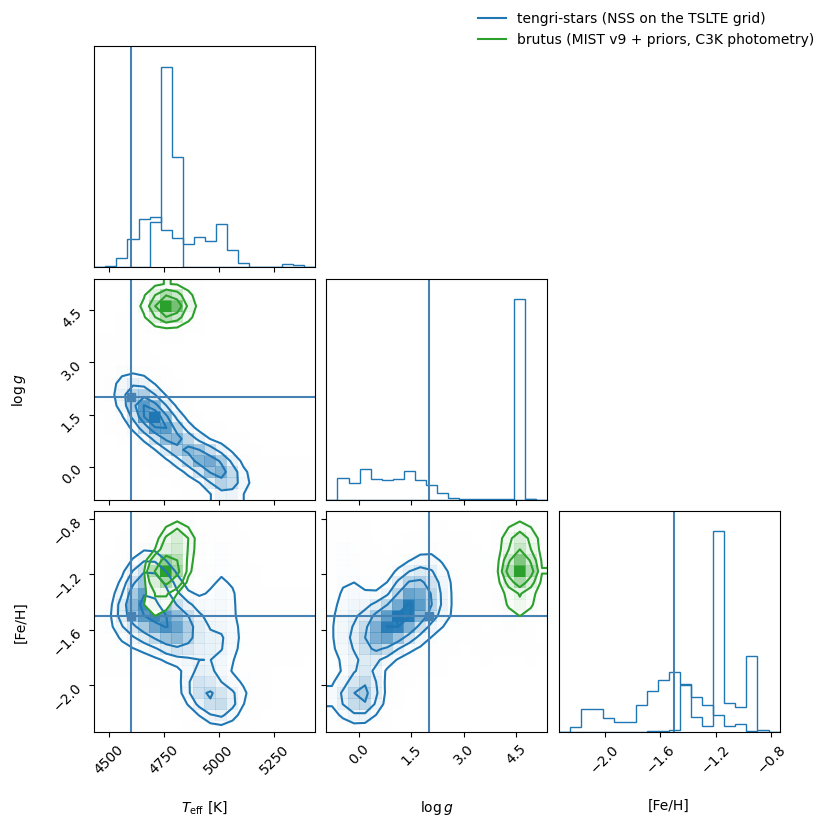

In [6]:
shared = ["teff", "logg", "feh"]
labels_tex = [r"$T_{\rm eff}$ [K]", r"$\log g$", "[Fe/H]"]
truth_vec = [TRUTH["teff"], TRUTH["logg"], TRUTH["feh"]]

fig = overlay_corner(
    [ts.samples, brutus_samples],
    names=shared,
    labels=labels_tex,
    colors=["C0", "C2"],
    legend_labels=[
        "tengri-stars (NSS on the TSLTE grid)",
        "brutus (MIST v9 + priors, C3K photometry)",
    ],
    truths={k: v for k, v in TRUTH.items() if k in shared},
)
plt.show()

In [7]:
print(f"{'':8s}{'truth':>9s}{'brutus':>22s}{'tengri-stars':>22s}")
for k, tv in zip(shared, truth_vec):
    b = np.percentile(np.asarray(brutus_samples[k], dtype=float), [16, 50, 84])
    t = np.percentile(np.asarray(ts.samples[k]), [16, 50, 84])
    print(
        f"{k:8s}{tv:9.2f}{b[1]:10.2f} [{b[0]:7.2f},{b[2]:7.2f}]"
        f"{t[1]:10.2f} [{t[0]:7.2f},{t[2]:7.2f}]"
    )

            truth                brutus          tengri-stars
teff      4600.00   4779.07 [4751.62,4818.31]   4788.29 [4656.64,5002.76]
logg         2.00      4.72 [   4.68,   4.73]      0.85 [  -0.10,   1.79]
feh         -1.50     -1.20 [  -1.25,  -0.95]     -1.54 [  -1.93,  -1.32]


## 6. Is brutus's tightness real? Diagnostics

BruteForce is an exhaustive scan, so it cannot "fail to converge" — but a
posterior can still be untrustworthy three ways: **misspecification collapse**
(no model fits, so likelihood ratios between the least-bad island and
everything else explode), **weight culling** (`wt_thresh=1e-3` deletes
subdominant modes), and **quantization** (equal-weight draws recycling a
handful of grid models). All three are checkable.

In [8]:
with h5py.File(DATA / "brutus" / "tslte_mock_fit.h5", "r") as f:
    chi2min = float(f["obj_chi2min"][0])
    n_unique = int(np.unique(f["model_idx"][0]).size)
print(f"chi2min = {chi2min:.1f} over {len(BRUTUS_BANDS)} bands — no model fits: the")
print("TSLTE↔C3K systematic is ~0.06 mag RMS against 0.02 mag error bars.")
print(f"unique models behind the 1000 draws: {n_unique} — heavily quantized.")

chi2min = 82.1 over 8 bands — no model fits: the
TSLTE↔C3K systematic is ~0.06 mag RMS against 0.02 mag error bars.
unique models behind the 1000 draws: 31 — heavily quantized.


The honest refit inflates the errors to absorb the grid systematic
(σ_eff = 0.07 mag → expected χ²_min ≈ n_bands) and lowers the culling
threshold so subdominant modes survive.

In [9]:
flux_r, ferr_r = brutus_utils.inv_magnitude(mags_obs, np.full(len(BRUTUS_BANDS), 0.07))
bf.fit(
    flux_r[None, :],
    ferr_r[None, :],
    np.ones((1, len(BRUTUS_BANDS)), dtype=bool),
    np.array([0]),
    str(DATA / "brutus" / "tslte_mock_relaxed"),
    data_coords=np.array([[90.0, 60.0]]),
    av_gauss=(0.0, 0.01),
    Ndraws=2500,
    wt_thresh=1e-6,
    rstate=np.random.RandomState(4),
    verbose=False,
)
with h5py.File(DATA / "brutus" / "tslte_mock_relaxed.h5", "r") as f:
    idx_r = f["model_idx"][0]
    chi2_r = float(f["obj_chi2min"][0])
relaxed = {
    "teff": 10.0 ** labels["logt"][idx_r],
    "logg": labels["logg"][idx_r],
    "feh": labels["feh"][idx_r],
}
print(f"relaxed: chi2min = {chi2_r:.1f} (genuine fit), unique models = {np.unique(idx_r).size}")
for k, tv in zip(shared, truth_vec):
    q = np.percentile(np.asarray(relaxed[k], dtype=float), [2.5, 50, 97.5])
    print(f"  {k:5s} truth {tv:8.2f}: median {q[1]:8.2f}, 95% [{q[0]:7.2f}, {q[2]:7.2f}]")
print(f"  giant-branch mass (logg < 3.5): {float(np.mean(relaxed['logg'] < 3.5)):.1%}")

relaxed: chi2min = 6.7 (genuine fit), unique models = 237
  teff  truth  4600.00: median  4869.50, 95% [4631.55, 5065.99]
  logg  truth     2.00: median     4.65, 95% [   4.54,    4.79]
  feh   truth    -1.50: median    -0.75, 95% [  -1.83,   -0.10]
  giant-branch mass (logg < 3.5): 0.0%


## Reading the comparison (with diagnostics in hand)

The strict-error brutus posterior in §5 is **false-precision**: χ²_min = 82
over 8 bands means no MIST/C3K model reproduces the Turbospectrum photometry
at σ = 0.02 mag (the grids differ by ~0.06 mag RMS in these bands), so the
posterior collapsed onto the least-bad island — 31 grid models masquerading as
a ±0.03 dex log g measurement. Two separate conclusions survive the refit:

- **The dwarf preference is genuinely prior-driven.** With errors that admit
  the systematic (χ²_min ≈ 7) and no weight culling, the giant branch *still*
  receives ~0% of brutus's posterior mass: absent a parallax, the IMF +
  Galactic priors overwhelm colors that permit both solutions. tengri-stars'
  flat prior sits on the giant side instead. The cures, in order of power:
  parallax, a gravity-sensitive band, or per-class evidence comparison
  (Δlog Z from NSS — the Bayesian upgrade of MAGIC's parallax z-score).
- **The [Fe/H] offset was partly artifact**: the relaxed brutus 95% interval
  ([−1.8, −0.1]) covers the truth it previously excluded. What remains is a
  metal-rich *lean* from the C3K↔Turbospectrum u-band difference — the
  per-band zero-point calibration MAGIC-scale surveys need (brutus itself
  ships per-survey offset files for exactly this reason).
- **Methodological moral**: a tight posterior from a grid code is only as
  trustworthy as its χ²_min. tengri-stars fits carry no mismatch here by
  construction (the mock came from the fitted grid); on real stars both codes
  face this, and the χ²_min check belongs in every pipeline.
- The spectroscopic channel (notebook 01) is untouched by all of this: these
  are photometric-grid systematics only. TSLTE synthetic *spectra* grids, when
  available, slot into `SpectralGrid.from_arrays` for the joint fit.